In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
from tqdm import tqdm
from matplotlib import pyplot as plt
from datasets import load_dataset
import numpy as np

class KVcacheAnalysis:
    def __init__(self, model_name):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForCausalLM.from_pretrained(model_name)
        self.model.eval()
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)
        self.kv = None
        
    def process_questions_for_kvDistribution(self, questions):
        n_bins = 1000
        key_cache_hist = torch.zeros(n_bins, dtype=torch.float32, device=self.device)
        value_cache_hist = torch.zeros(n_bins, dtype=torch.float32, device=self.device)

        with torch.no_grad():
            for text in tqdm(questions):
                inputs = self.tokenizer(text, return_tensors="pt").to(self.device)
                outputs = self.model(**inputs, use_cache=True) # return the key-value pairs
                
                kvcache = outputs.past_key_values
                if kvcache:
                    self.kv = kvcache
                    for layer_kv in kvcache:
                        key_cache = layer_kv[0].reshape(-1).float()
                        value_cache = layer_kv[1].reshape(-1).float()
                        key_cache_hist += torch.histc(key_cache, bins=n_bins, min=-5.0, max=5.0)
                        value_cache_hist += torch.histc(value_cache, bins=n_bins, min=-5.0, max=5.0)

        self.plot_and_save(key_cache_hist.to('cpu').numpy(), value_cache_hist.to('cpu').numpy(), n_bins)

    def plot_and_save(self, key_cache_hist, value_cache_hist, n_bins):
        x_range = np.linspace(-5.0, 5.0, n_bins)
        plt.figure(figsize=(10, 5))
        plt.plot(x_range, key_cache_hist, label="Key Cache Distribution")
        plt.plot(x_range, value_cache_hist, label="Value Cache Distribution")
        plt.legend()
        plt.xlabel("Value")
        plt.ylabel("Count")
        plt.title("KV Cache Distributions")
        plt.show()

    def process_questions_for_kvDistribution_layer_wise(self, questions):
        n_bins = 1000
        
        sample_input = self.tokenizer(questions[0], return_tensors="pt").to(self.device)
        sample_output = self.model(**sample_input, use_cache=True)
        num_layers = len(sample_output.past_key_values)
        
        key_cache_hists = [torch.zeros(n_bins, dtype=torch.float32, device=self.device) for _ in range(num_layers)]
        value_cache_hists = [torch.zeros(n_bins, dtype=torch.float32, device=self.device) for _ in range(num_layers)]

        with torch.no_grad():
            for text in tqdm(questions):
                inputs = self.tokenizer(text, return_tensors="pt").to(self.device)
                outputs = self.model(**inputs, use_cache=True)
                
                kvcache = outputs.past_key_values
                for i, layer_kv in enumerate(kvcache):
                    key_cache = layer_kv[0].reshape(-1).float()
                    value_cache = layer_kv[1].reshape(-1).float()
                    key_cache_hists[i] += torch.histc(key_cache, bins=n_bins, min=-5.0, max=5.0)
                    value_cache_hists[i] += torch.histc(value_cache, bins=n_bins, min=-5.0, max=5.0)

        self.plot_layer_wise(key_cache_hists, value_cache_hists, n_bins)

    def plot_layer_wise(self, key_cache_hists, value_cache_hists, n_bins):
        num_layers = len(key_cache_hists)
        x_range = np.linspace(-5.0, 5.0, n_bins)
        fig, axes = plt.subplots(nrows=num_layers, ncols=2, figsize=(12, num_layers * 4))
        fig.suptitle('Layer-wise KV Cache Distributions')

        for i in range(num_layers):
            key_hist_np = key_cache_hists[i].cpu().numpy()
            value_hist_np = value_cache_hists[i].cpu().numpy()

            axes[i][0].plot(x_range, key_hist_np, label="Key Distribution")
            axes[i][1].plot(x_range, value_hist_np, label="Value Distribution")
            axes[i][0].set_title(f'Layer {i+1} Keys')
            axes[i][1].set_title(f'Layer {i+1} Values')
            axes[i][0].set_xlabel('Value')
            axes[i][1].set_xlabel('Value')
            axes[i][0].set_ylabel('Frequency')
            axes[i][1].set_ylabel('Frequency')
            axes[i][0].legend()
            axes[i][1].legend()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

100%|██████████| 100/100 [00:01<00:00, 55.47it/s]


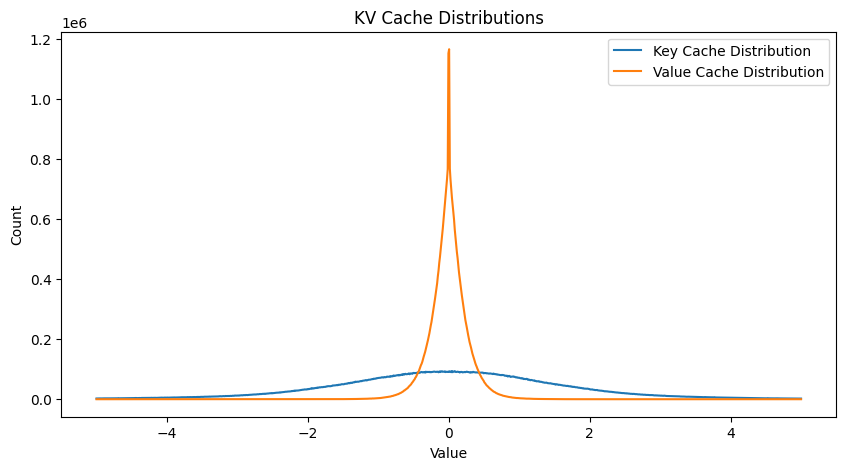

100%|██████████| 100/100 [00:01<00:00, 55.93it/s]


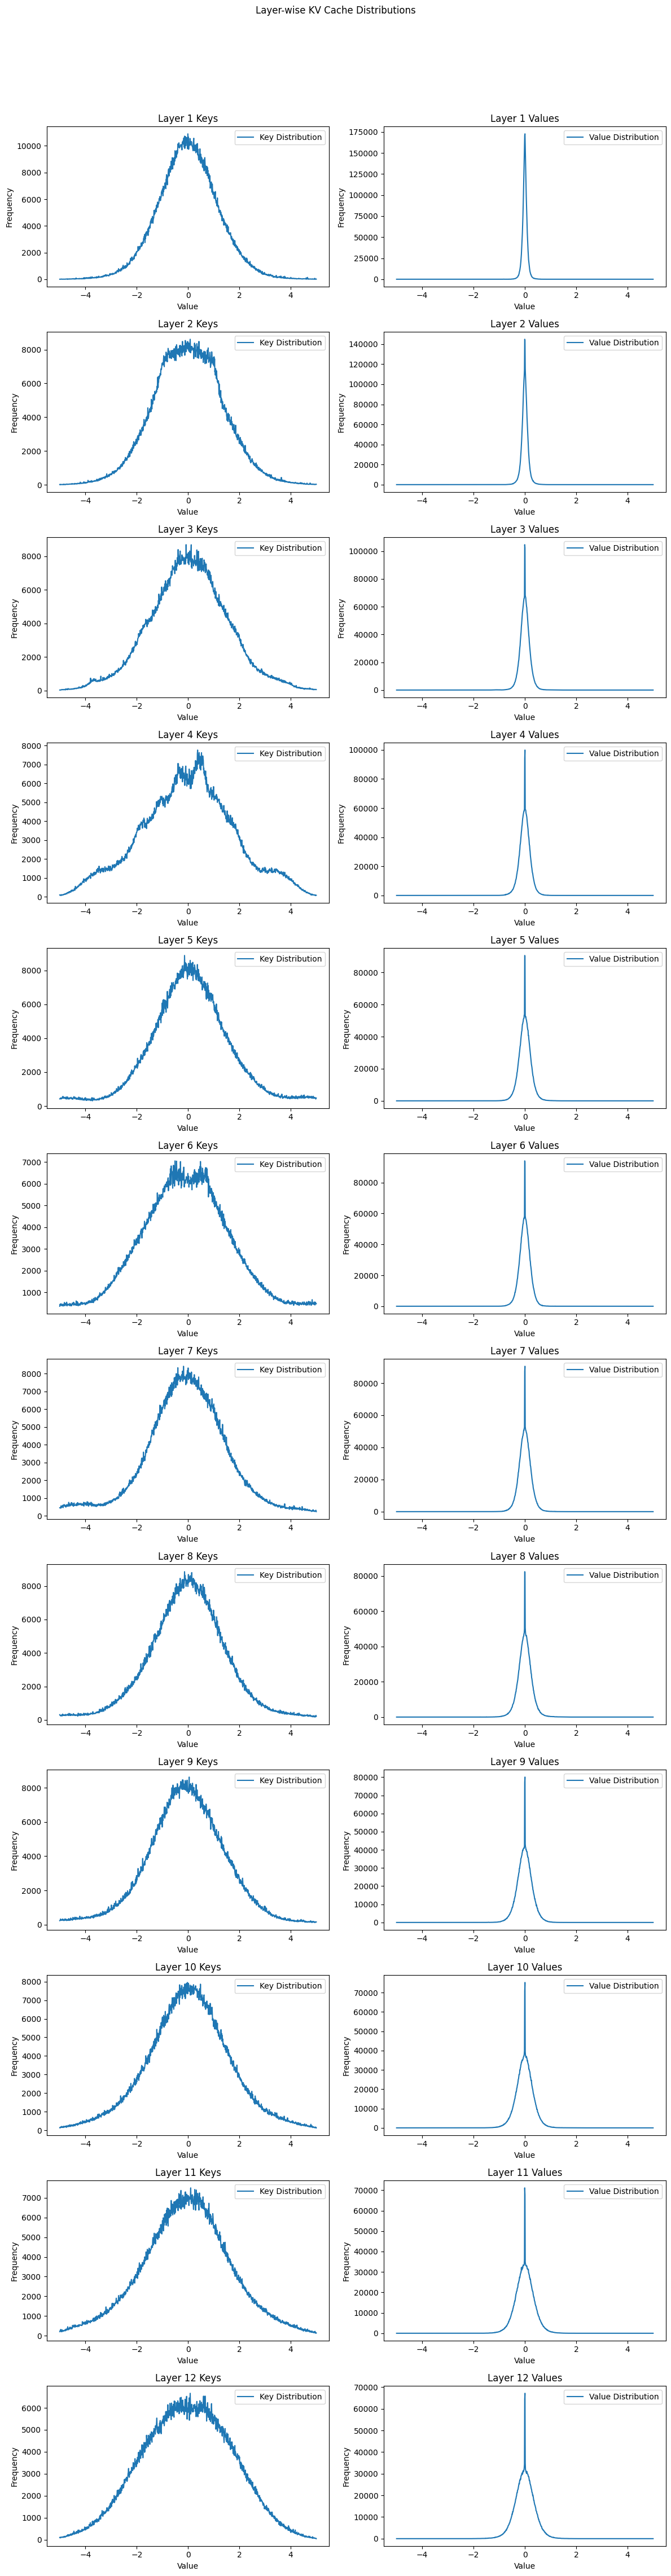

In [57]:
dataset = load_dataset("cais/mmlu", "abstract_algebra", split='test')
questions = [q['question'] for q in dataset]
model_kv = KVcacheAnalysis('facebook/opt-125m')
model_kv.process_questions_for_kvDistribution(questions)
model_kv.process_questions_for_kvDistribution_layer_wise(questions)

100%|██████████| 100/100 [00:02<00:00, 46.99it/s]


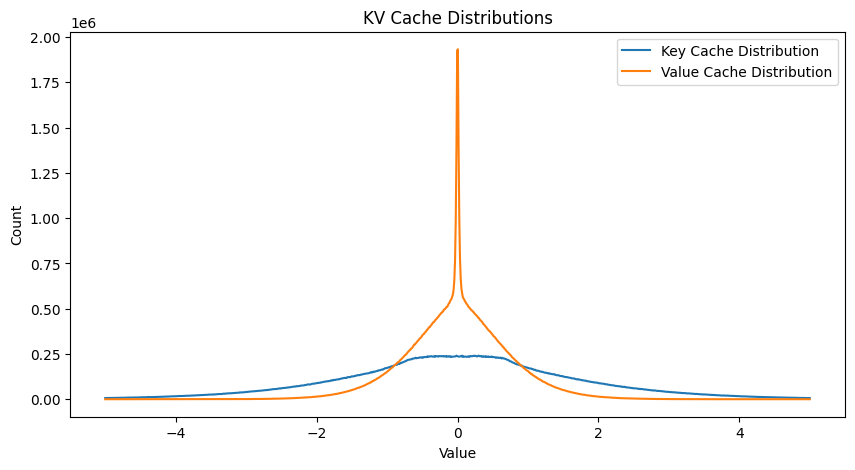

In [18]:
dataset = load_dataset("cais/mmlu", "abstract_algebra", split='test')
questions = [q['question'] for q in dataset]
model_kv = KVcacheAnalysis('facebook/opt-350m')
model_kv.process_questions_for_kvDistribution(questions)
# model_kv.process_questions_for_kvDistribution_layer_wise(questions)

100%|██████████| 100/100 [00:13<00:00,  7.66it/s]


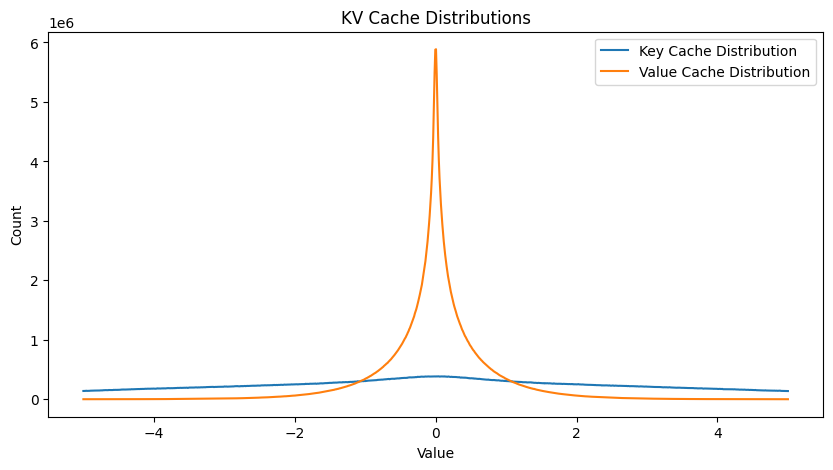

In [19]:
dataset = load_dataset("cais/mmlu", "abstract_algebra", split='test')
questions = [q['question'] for q in dataset]
model_kv = KVcacheAnalysis('facebook/opt-2.7b')
model_kv.process_questions_for_kvDistribution(questions)

100%|██████████| 100/100 [00:03<00:00, 27.99it/s]


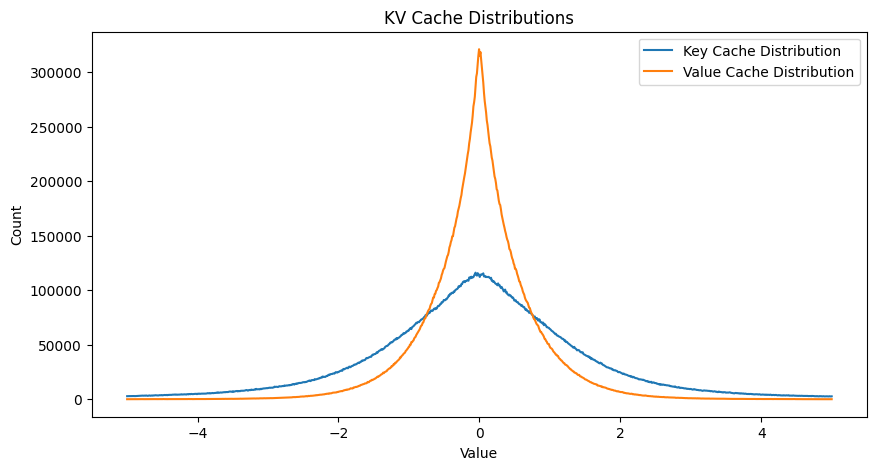

In [3]:
# GPT2
dataset = load_dataset("cais/mmlu", "abstract_algebra", split='test')
questions = [q['question'] for q in dataset]
model_kv = KVcacheAnalysis('openai-community/gpt2')
model_kv.process_questions_for_kvDistribution(questions)
# model_kv.process_questions_for_kvDistribution_layer_wise(questions)

In [122]:
import numpy as np
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch
import matplotlib.pyplot as plt

def plot_kv_stats(kv_stats):
    layers = [stat['layer'] for stat in kv_stats]
    key_means = [stat['mean_keys'] for stat in kv_stats]
    value_means = [stat['mean_values'] for stat in kv_stats]
    key_stds = [stat['std_keys'] for stat in kv_stats]
    value_stds = [stat['std_values'] for stat in kv_stats]

    plt.figure(figsize=(6,3))
    plt.plot(layers, key_means, label='Key Means', marker='.')
    plt.plot(layers, value_means, label='Value Means', marker='.')
    plt.title('Means per Layer')
    plt.xlabel('Layer')
    plt.ylabel('mean')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6,3))
    plt.plot(layers, key_stds, label='Key Std Devs', marker='.')
    plt.plot(layers, value_stds, label='Value Std Devs', marker='.')
    plt.title('Std per Layer')
    plt.xlabel('Layer')
    plt.ylabel('sd')
    plt.legend()
    plt.grid(True)
    plt.show()
    
def analyze_kv_pairs(past_key_values):
    kv_stats = []
    all_keys = []
    all_values = []
    
    for layer_index, (keys, values) in enumerate(past_key_values):
        keys_flat = keys.reshape(-1).float()
        values_flat = values.reshape(-1).float()
        
        all_keys.append(keys_flat)
        all_values.append(values_flat)
        
        kv_stats.append({
            'layer': layer_index + 1,
            'mean_keys': keys_flat.mean().item(),
            'std_keys': keys_flat.std().item(),
            'mean_values': values_flat.mean().item(),
            'std_values': values_flat.std().item(),
        })
    all_keys = torch.cat(all_keys)
    all_values = torch.cat(all_values)
    
    mean_keys = all_keys.mean()
    std_keys = all_keys.std()
    mean_values = all_values.mean()
    std_values = all_values.std()
    
    all_stats = {
        'total_mean_keys': mean_keys.item(),
        'total_std_keys': std_keys.item(),
        'total_min_keys': all_keys.min().item(),
        'total_max_keys': all_keys.max().item(),
        
        'total_mean_values': mean_values.item(),
        'total_std_values': std_values.item(),
        'total_min_values': all_values.min().min().item(),
        'total_max_values': all_values.max().item(),
        'percent_within_1_std_keys': ((all_keys >= (mean_keys - std_keys)) & (all_keys <= (mean_keys + std_keys))).float().mean().item() * 100,
        'percent_within_1_std_values': ((all_values >= (mean_values - std_values)) & (all_values <= (mean_values + std_values))).float().mean().item() * 100
    }

    return kv_stats, all_stats

facebook/opt-125m: 
  layer 1: key mean: 0.00998732727020979, key std: 1.141134262084961
  layer 2: key mean: 0.010145353153347969, key std: 1.3119850158691406
  layer 3: key mean: 0.016206707805395126, key std: 1.4395893812179565
  layer 4: key mean: -0.019967159256339073, key std: 1.7082855701446533
  layer 5: key mean: 0.08087071031332016, key std: 1.7088778018951416
  layer 6: key mean: -0.0570061132311821, key std: 1.8674925565719604
  layer 7: key mean: -0.06529945880174637, key std: 1.7260690927505493
  layer 8: key mean: -0.02441285364329815, key std: 1.660349726676941
  layer 9: key mean: -0.057307254523038864, key std: 1.6502350568771362
  layer 10: key mean: 0.02387269027531147, key std: 1.6806937456130981
  layer 11: key mean: -0.06944289058446884, key std: 1.8351898193359375
  layer 12: key mean: 0.005348206963390112, key std: 1.7635107040405273

  layer 1: value mean: -0.0016889208927750587, value std: 0.10183635354042053
  layer 2: value mean: -0.001157489256002009, valu

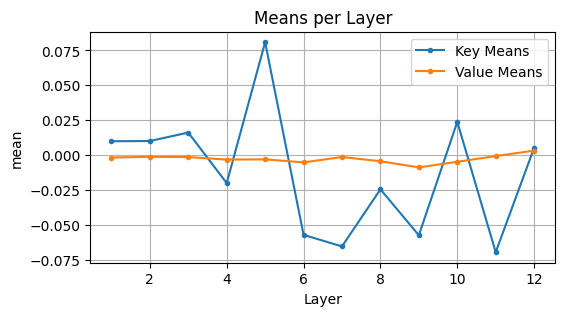

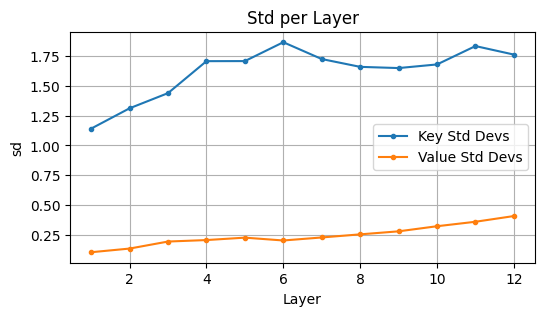

In [123]:
print("facebook/opt-125m: ")
tokenizer = AutoTokenizer.from_pretrained('facebook/opt-125m')
model = AutoModelForCausalLM.from_pretrained('facebook/opt-125m')
model.eval()
model.to("cuda" if torch.cuda.is_available() else "cpu")

question = "Find the degree for the given field extension Q(sqrt(2), sqrt(3), sqrt(18)) over Q."
inputs = tokenizer(question, return_tensors="pt").to(model.device)
outputs = model(**inputs, use_cache=True)
kv_stats, kv_all_stats = analyze_kv_pairs(outputs.past_key_values) 


for stat in kv_stats:
    print(f"  layer {stat['layer']}: key mean: {stat['mean_keys']}, key std: {stat['std_keys']}")
print()
for stat in kv_stats:
    print(f"  layer {stat['layer']}: value mean: {stat['mean_values']}, value std: {stat['std_values']}")

print("------ overall KV Cache statistics ------")
print(f"  key -- mean: {kv_all_stats['total_mean_keys']}, std: {kv_all_stats['total_std_keys']}, min: {kv_all_stats['total_min_keys']}, max: {kv_all_stats['total_max_keys']}")
print(f"  value -- mean: {kv_all_stats['total_mean_values']}, std: {kv_all_stats['total_std_values']}, min: {kv_all_stats['total_min_values']}, max: {kv_all_stats['total_max_values']}")
print(f"  percent_within_1_std_keys: {kv_all_stats['percent_within_1_std_keys']}")
print(f"  percent_within_1_std_values: {kv_all_stats['percent_within_1_std_values']}")

kv_stats = analyze_kv_pairs(outputs.past_key_values)[0]
plot_kv_stats(kv_stats)

facebook/opt-350m: 
  layer 1: key mean: -0.005589307751506567, key std: 0.5967018604278564
  layer 2: key mean: 0.015549718402326107, key std: 2.1242806911468506
  layer 3: key mean: 0.09285101294517517, key std: 2.2622182369232178
  layer 4: key mean: 0.015788517892360687, key std: 2.0379769802093506
  layer 5: key mean: -0.04997200146317482, key std: 1.8328114748001099
  layer 6: key mean: 0.05402124673128128, key std: 1.6674745082855225
  layer 7: key mean: -0.030175792053341866, key std: 1.9409871101379395
  layer 8: key mean: -0.02066810429096222, key std: 2.0235302448272705
  layer 9: key mean: 0.01590527966618538, key std: 2.0353026390075684
  layer 10: key mean: -0.12171214073896408, key std: 2.05845046043396
  layer 11: key mean: 0.02410399168729782, key std: 1.652392864227295
  layer 12: key mean: 0.07054207473993301, key std: 1.6046398878097534
  layer 13: key mean: 0.01848575845360756, key std: 1.494096040725708
  layer 14: key mean: 0.021793391555547714, key std: 1.529286

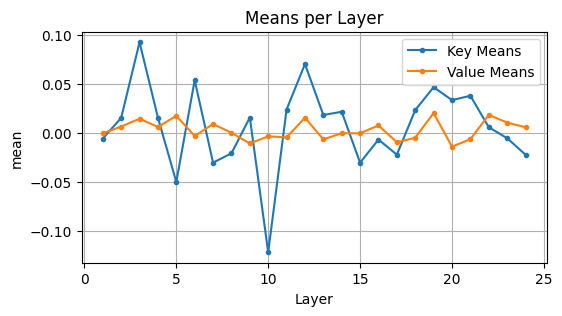

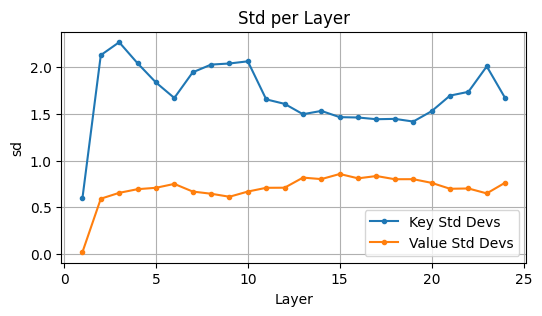

In [125]:
print("facebook/opt-350m: ")
tokenizer = AutoTokenizer.from_pretrained('facebook/opt-350m')
model = AutoModelForCausalLM.from_pretrained('facebook/opt-350m')
model.eval()
model.to("cuda" if torch.cuda.is_available() else "cpu")

inputs = tokenizer(question, return_tensors="pt").to(model.device)
outputs = model(**inputs, use_cache=True)
kv_stats, kv_all_stats = analyze_kv_pairs(outputs.past_key_values) 

for stat in kv_stats:
    print(f"  layer {stat['layer']}: key mean: {stat['mean_keys']}, key std: {stat['std_keys']}")
print()
for stat in kv_stats:
    print(f"  layer {stat['layer']}: value mean: {stat['mean_values']}, value std: {stat['std_values']}")

print("------ overall KV Cache statistics ------")
print(f"  key -- mean: {kv_all_stats['total_mean_keys']}, std: {kv_all_stats['total_std_keys']}, min: {kv_all_stats['total_min_keys']}, max: {kv_all_stats['total_max_keys']}")
print(f"  value -- mean: {kv_all_stats['total_mean_values']}, std: {kv_all_stats['total_std_values']}, min: {kv_all_stats['total_min_values']}, max: {kv_all_stats['total_max_values']}")
print(f"  percent_within_1_std_keys: {kv_all_stats['percent_within_1_std_keys']}")
print(f"  percent_within_1_std_values: {kv_all_stats['percent_within_1_std_values']}")

kv_stats = analyze_kv_pairs(outputs.past_key_values)[0]
plot_kv_stats(kv_stats)

gpt2: 
------ overall KV Cache statistics ------
  key -- mean: -0.02479412592947483, std: 2.095315456390381, min: -21.10565948486328, max: 21.912628173828125
  value -- mean: 0.00418861722573638, std: 0.7610679268836975, min: -13.389050483703613, max: 13.425131797790527
  percent_within_1_std_keys: 81.44415616989136
  percent_within_1_std_values: 75.84248185157776


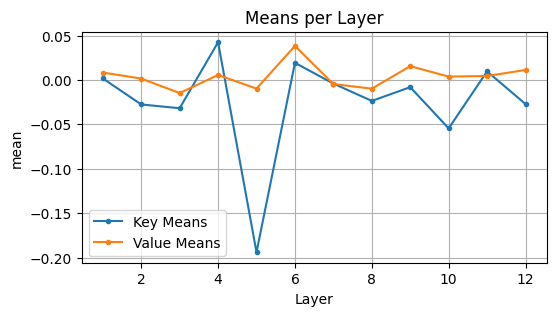

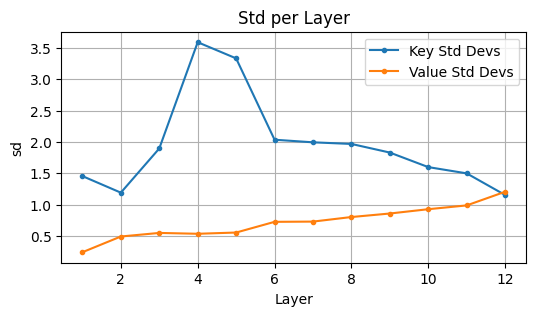

In [124]:
print("gpt2: ")
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()
model.to("cuda" if torch.cuda.is_available() else "cpu")

inputs = tokenizer(question, return_tensors="pt").to(model.device)
outputs = model(**inputs, use_cache=True)
kv_stats, kv_all_stats = analyze_kv_pairs(outputs.past_key_values)

# for stat in kv_stats:
#     print(f"  layer {stat['layer']}: key mean: {stat['mean_keys']}, key std: {stat['std_keys']}")
# print()
# for stat in kv_stats:
#     print(f"  layer {stat['layer']}: value mean: {stat['mean_values']}, value std: {stat['std_values']}")

print("------ overall KV Cache statistics ------")
print(f"  key -- mean: {kv_all_stats['total_mean_keys']}, std: {kv_all_stats['total_std_keys']}, min: {kv_all_stats['total_min_keys']}, max: {kv_all_stats['total_max_keys']}")
print(f"  value -- mean: {kv_all_stats['total_mean_values']}, std: {kv_all_stats['total_std_values']}, min: {kv_all_stats['total_min_values']}, max: {kv_all_stats['total_max_values']}")
print(f"  percent_within_1_std_keys: {kv_all_stats['percent_within_1_std_keys']}")
print(f"  percent_within_1_std_values: {kv_all_stats['percent_within_1_std_values']}")

kv_stats = analyze_kv_pairs(outputs.past_key_values)[0]
plot_kv_stats(kv_stats)

In [20]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
import math
from collections import Counter, defaultdict
from tqdm import tqdm

def load_model(model_name):
    model = AutoModelForCausalLM.from_pretrained(model_name).to("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    return model, tokenizer

def analyze_kv_exponents_and_mantissas(kv_pairs):
    exponent_counts = Counter()
    mantissa_counts = defaultdict(int)
    total_params = sum(kv_pair.numel() for layer_kv in kv_pairs for kv_pair in layer_kv)
    for layer_kv in kv_pairs:
        for kv_pair in layer_kv:
            kv_data = kv_pair.cpu().detach().numpy().flatten()
            bias = 15 if kv_pair.dtype == torch.float16 else 127  
            mantissa_shift = 10 if kv_pair.dtype == torch.float16 else 23 

            for data in kv_data:
                mantissa, exponent = math.frexp(data) 
                exponent_bin = f"{exponent + bias:08b}" 
                mantissa_bin = f"{int((mantissa * 2) * (2**mantissa_shift)):023b}"  
                exponent_counts[exponent_bin] += 1
                mantissa_counts[mantissa_bin] += 1
    

    return exponent_counts, mantissa_counts

def print_distribution(counts, description, limit=15):
    total_counts = sum(counts.values())
    print(f"\n{description}:")
    sorted_counts = sorted(counts.items(), key=lambda item: item[1], reverse=True)
    for index, (key, count) in enumerate(sorted_counts):
        if limit is not None and index >= limit:
            break
        percentage = (count / total_counts) * 100
        print(f"{key}: {percentage:.2f}% ({count} times)")

In [22]:
model_name = "facebook/opt-125m"
model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype="auto").to("cuda" if torch.cuda.is_available() else "cpu")
model.eval()
tokenizer = AutoTokenizer.from_pretrained(model_name)

inputs = tokenizer(question, return_tensors="pt").to(model.device)
outputs = model(**inputs, use_cache=True)

exponent_counts, mantissa_counts = analyze_kv_exponents_and_mantissas(outputs.past_key_values)
print_distribution(exponent_counts, 'Exponents')
print_distribution(mantissa_counts, 'Mantissas')



Exponents:
00001110: 16.56% (158741 times)
00001101: 16.22% (155493 times)
00010000: 15.21% (145816 times)
00001111: 14.46% (138627 times)
00001100: 11.80% (113053 times)
00010001: 8.69% (83289 times)
00001011: 6.98% (66905 times)
00001010: 3.78% (36185 times)
00001001: 1.99% (19119 times)
00010010: 1.60% (15303 times)
00001000: 1.15% (10990 times)
00000111: 0.72% (6920 times)
00000110: 0.40% (3859 times)
00000101: 0.22% (2091 times)
00000100: 0.11% (1049 times)

Mantissas:
00000000000010000010000: 0.09% (852 times)
00000000000010001000000: 0.09% (851 times)
-0000000000010000010000: 0.09% (815 times)
-0000000000010010000000: 0.08% (809 times)
-0000000000010000001000: 0.08% (808 times)
00000000000010000011000: 0.08% (801 times)
00000000000010000100000: 0.08% (794 times)
00000000000010000000000: 0.08% (790 times)
-0000000000010001010000: 0.08% (779 times)
-0000000000010000011000: 0.08% (776 times)
00000000000010000001100: 0.08% (775 times)
-0000000000010000100000: 0.08% (774 times)
-000

In [23]:
model_name = "gpt2"
model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype="auto").to("cuda" if torch.cuda.is_available() else "cpu")
model.eval()
tokenizer = AutoTokenizer.from_pretrained(model_name)

inputs = tokenizer(question, return_tensors="pt").to(model.device)
outputs = model(**inputs, use_cache=True)

exponent_counts, mantissa_counts = analyze_kv_exponents_and_mantissas(outputs.past_key_values)
print_distribution(exponent_counts, 'Exponents')
print_distribution(mantissa_counts, 'Mantissas')



Exponents:
01111111: 23.72% (222960 times)
10000000: 19.34% (181781 times)
01111110: 18.95% (178094 times)
01111101: 12.22% (114893 times)
10000001: 8.02% (75401 times)
01111100: 6.96% (65405 times)
01111011: 3.75% (35229 times)
10000010: 2.55% (23925 times)
01111010: 1.95% (18342 times)
01111001: 0.97% (9126 times)
10000011: 0.61% (5704 times)
01111000: 0.49% (4565 times)
01110111: 0.23% (2208 times)
01110110: 0.12% (1126 times)
01110101: 0.06% (588 times)

Mantissas:
-100000110100101110111101: 0.00% (4 times)
-110001010000100001010101: 0.00% (4 times)
-101101110000000110000110: 0.00% (4 times)
100001010011001000111110: 0.00% (4 times)
-100000100111010000100110: 0.00% (4 times)
101000100011011110100100: 0.00% (4 times)
100011101010101101010000: 0.00% (3 times)
-101100111111110100010010: 0.00% (3 times)
101101010001001011110010: 0.00% (3 times)
100101000011101011100010: 0.00% (3 times)
-101001100110010000010011: 0.00% (3 times)
-100001001001001010001100: 0.00% (3 times)
10111101111101

In [13]:
def analyze_k_and_v(kv_pairs):
    key_exponent_counts = Counter()
    key_mantissa_counts = defaultdict(int)
    value_exponent_counts = Counter()
    value_mantissa_counts = defaultdict(int)
    
    for layer_index, layer_kv in enumerate(kv_pairs):
        keys, values = layer_kv
        analyze_tensor(keys, key_exponent_counts, key_mantissa_counts)
        analyze_tensor(values, value_exponent_counts, value_mantissa_counts)

    return (key_exponent_counts, key_mantissa_counts), (value_exponent_counts, value_mantissa_counts)

def analyze_tensor(tensor, exponent_counts, mantissa_counts):
    tensor_data = tensor.cpu().detach().numpy().flatten()
    # fp32 default
    bias = 127 
    mantissa_shift = 23 
    
    # fp16
    if tensor.dtype == torch.float16:
        bias = 15 
        mantissa_shift = 10 

    for data in tensor_data:
        mantissa, exponent = math.frexp(data)
        exponent_bin = f"{exponent + bias:08b}"
        mantissa_bin = f"{int((mantissa * 2) * (2**mantissa_shift)):023b}"
        exponent_counts[exponent_bin] += 1
        mantissa_counts[mantissa_bin] += 1


model_name = "gpt2"
model = AutoModelForCausalLM.from_pretrained(model_name).to("cuda" if torch.cuda.is_available() else "cpu")
model.eval()
tokenizer = AutoTokenizer.from_pretrained(model_name)
question = 'Statement 1 | The set of 2 x 2 matrices with integer entries and nonzero determinant is a group under matrix multiplication. Statement 2 | The set of 2 x 2 matrices with integer entries and determinant 1 is a group under matrix multiplication.'
inputs = tokenizer(question, return_tensors="pt").to(model.device)
outputs = model(**inputs, use_cache=True)

(key_exponent_counts, key_mantissa_counts), (value_exponent_counts, value_mantissa_counts) = analyze_k_and_v(outputs.past_key_values)

print_distribution(key_exponent_counts, 'Key Exponents')
print_distribution(key_mantissa_counts, 'Key Mantissas')
print_distribution(value_exponent_counts, 'Value Exponents')
print_distribution(value_mantissa_counts, 'Value Mantissas')



Key Exponents:
10000000: 25.45% (119610 times)
01111111: 23.14% (108767 times)
01111110: 14.66% (68881 times)
10000001: 13.95% (65567 times)
01111101: 8.14% (38255 times)
10000010: 4.99% (23435 times)
01111100: 4.20% (19754 times)
01111011: 2.13% (10002 times)
10000011: 1.21% (5681 times)
01111010: 1.06% (5000 times)
01111001: 0.52% (2458 times)
01111000: 0.26% (1243 times)
01110111: 0.13% (597 times)
01110110: 0.07% (318 times)
01110101: 0.03% (155 times)

Key Mantissas:
-100000110100101110111101: 0.00% (4 times)
-101001100110010000010011: 0.00% (3 times)
110011011100110001101001: 0.00% (3 times)
101100000000010011100100: 0.00% (3 times)
100000101101001001110110: 0.00% (3 times)
100100010001011110111110: 0.00% (3 times)
-100101100100000010001100: 0.00% (3 times)
101100100101110111001011: 0.00% (3 times)
100110111010101010111001: 0.00% (3 times)
-110011111011010011001010: 0.00% (3 times)
100000110011000011110000: 0.00% (3 times)
-101101110000000110000110: 0.00% (3 times)
-101100010110

In [16]:
from collections import Counter
from tqdm import tqdm
import torch

def analyze_kv_bytes(kv_pairs):
    byte_counts = Counter()
    total_elements = sum(kv_pair.numel() for layer_kv in kv_pairs for kv_pair in layer_kv for tensor in kv_pair)
    
    for layer_kv in kv_pairs:
        for kv_tensor in layer_kv:
            tensor_data = kv_tensor.cpu().detach().numpy()
            for data in tensor_data.flatten():
                weight_bytes = data.tobytes()
                for b in weight_bytes:
                    byte_counts[f'{b:02x}'] += 1
    
    return byte_counts, total_elements

In [17]:
print("facebook/opt-125m: ")
tokenizer = AutoTokenizer.from_pretrained('facebook/opt-125m')
model = AutoModelForCausalLM.from_pretrained('facebook/opt-125m')
model.eval()
model.to("cuda" if torch.cuda.is_available() else "cpu")

question = 'Statement 1 | The set of 2 x 2 matrices with integer entries and nonzero determinant is a group under matrix multiplication. Statement 2 | The set of 2 x 2 matrices with integer entries and determinant 1 is a group under matrix multiplication.'
inputs = tokenizer(question, return_tensors="pt").to(model.device)
outputs = model(**inputs, use_cache=True)
kv_byte_counts, total_counts = analyze_kv_bytes(outputs.past_key_values)

print("byte counts:")
for byte, count in kv_byte_counts.most_common(10):
    percentage = (count / total_counts) * 100  
    print(f"{byte}: {percentage:.2f}% ({count} times)") 


facebook/opt-125m: 
byte counts:
be: 17.74% (169991 times)
3e: 17.51% (167817 times)
3f: 15.88% (152185 times)
bf: 15.81% (151554 times)
bd: 10.40% (99722 times)
3d: 10.40% (99633 times)
c0: 6.87% (65883 times)
40: 6.64% (63687 times)
bc: 4.24% (40646 times)
3c: 4.16% (39903 times)


In [20]:
print("facebook/opt-350m: ")
tokenizer = AutoTokenizer.from_pretrained('facebook/opt-350m')
model = AutoModelForCausalLM.from_pretrained('facebook/opt-350m')
model.eval()
model.to("cuda" if torch.cuda.is_available() else "cpu")

question = "Statement 1 | A factor group of a non-Abelian group is non-Abelian. Statement 2 | If K is a normal subgroup of H and H is a normal subgroup of G, then K is a normal subgroup of G."
inputs = tokenizer(question, return_tensors="pt").to(model.device)
outputs = model(**inputs, use_cache=True)
kv_byte_counts, total_counts = analyze_kv_bytes(outputs.past_key_values)

print("byte counts:")
for byte, count in kv_byte_counts.most_common(10):
    percentage = (count / total_counts) * 100  
    print(f"{byte}: {percentage:.2f}% ({count} times)") 


facebook/opt-350m: 
byte counts:
3f: 23.98% (636356 times)
bf: 23.89% (634038 times)
3e: 15.32% (406676 times)
be: 15.20% (403536 times)
40: 7.80% (207031 times)
c0: 7.77% (206264 times)
3d: 5.23% (138898 times)
bd: 5.19% (137786 times)
3c: 3.08% (81626 times)
bc: 3.05% (80965 times)


In [18]:
print("gpt2: ")
tokenizer = AutoTokenizer.from_pretrained('gpt2')
model = AutoModelForCausalLM.from_pretrained('gpt2')
model.eval()
model.to("cuda" if torch.cuda.is_available() else "cpu")

question = 'Statement 1 | The set of 2 x 2 matrices with integer entries and nonzero determinant is a group under matrix multiplication. Statement 2 | The set of 2 x 2 matrices with integer entries and determinant 1 is a group under matrix multiplication.'
inputs = tokenizer(question, return_tensors="pt").to(model.device)
outputs = model(**inputs, use_cache=True)
kv_byte_counts, total_counts = analyze_kv_bytes(outputs.past_key_values)

print("byte counts:")
for byte, count in kv_byte_counts.most_common(10):
    percentage = (count / total_counts) * 100  
    print(f"{byte}: {percentage:.2f}% ({count} times)") 


gpt2: 
byte counts:
3f: 22.77% (214016 times)
bf: 22.51% (211622 times)
3e: 16.82% (158118 times)
be: 16.72% (157164 times)
c0: 6.75% (63448 times)
3d: 6.49% (61052 times)
bd: 6.45% (60666 times)
40: 6.33% (59516 times)
bc: 2.69% (25241 times)
3c: 2.65% (24954 times)
